In [2]:
import pandas as pd
import numpy as np

In [3]:
#!pip install openpyxl

In [4]:
file_path = "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Baseline_Characteristics_raw_data/Final_baseline_characteristics_sorted_by_outcomegroups.xlsx"
df = pd.read_excel(file_path)

print(df.shape)
print(df.columns.tolist())
df.head()

(100, 53)
['ID', 'response_group', 'sex_female0_male1', 'Body mass index', 'Body surface area (m2)', 'years_since_first_diagnosis', 'age_at_TASH', 'year_of_TASH', 'years_since_TASH', 'multiple_TASH', 'Hypertonie ', 'Diabetes ', 'Dylipidämie', 'Vorhofflimmern', 'Betablocker', 'Verapamil', 'Baseline Angina', 'Baseline VT', 'Baseline nsVT', 'Baseline SCD in family', 'Baseline Schwindel ', 'Baseline Synkopen ', 'ESC_SCD_Score_BL', 'LVOTrest_vor_TASH ', 'LVOTres_nach_TASH', 'LVOTres_1st_year', 'LVOTrest_last_FU', 'LVOTrest_DELTA_rest_LVOT', 'LVOTpeak_vor_TASH ', 'LVOTpeak_1st_year', 'LVOTpeak_last_FU', 'LVOTpeak_DELTA_peak_LVOT', 'IVSDd_vor_TASH ', 'IVSDd_nach_TASH', 'IVSDd_last_FU', 'LAVI_vor_TASH ', 'LAVI_nach_TASH', 'LAVI_last_FU', 'DELTA_LAVI', 'LVEF_vor_TASH ', 'LVEF_last_FU', 'DELTA_LVEF', 'KCCQ_last_FU', 'NYHA_vor_TASH ', 'NYHA_last_FU', 'DELTA_NYHA (Improve)', 'NT-proBNP_BL', 'Device_before_TASH', 'NEW_Device_after_TASH', 'AV_block_after_TASH', 'NEW_RSB/LSB_after_TASH_no1_yes1', 'NE

,ID,response_group,sex_female0_male1,Body mass index,Body surface area (m2),years_since_first_diagnosis,age_at_TASH,year_of_TASH,years_since_TASH,multiple_TASH,...,NYHA_vor_TASH,NYHA_last_FU,DELTA_NYHA (Improve),NT-proBNP_BL,Device_before_TASH,NEW_Device_after_TASH,AV_block_after_TASH,NEW_RSB/LSB_after_TASH_no1_yes1,NEW_LSB_after_TASH,NEW_RSB_after_TASH
0,Al16233,1,0,26.08,1.804,6.0,74,2019-05-07,6.0,NaN,...,3,1,-2,NaN,1,0,0,0,0,0
1,Al21494,1,1,29.38,2.109,6.0,60,2019-05-27,6.0,NaN,...,2,1,-1,NaN,0,0,0,0,0,0
2,Al22533,3,1,23.51,1.871,10.0,54,2015-12-04,10.0,NaN,...,2,3,1,NaN,1,0,0,0,0,0
3,Al25823,1,1,27.64,1.908,9.0,45,2016-08-02,9.0,NaN,...,2,1,-1,NaN,0,0,0,0,0,0
4,Al26868,2,1,28.40,2.021,20.0,31,2005-01-20,20.0,NaN,...,1,2,1,475.0,0,1,1,1,0,1


In [5]:
# Strip accidental spaces from column names
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())
print(df["response_group"].value_counts(dropna=False).sort_index())

(100, 53)
['ID', 'response_group', 'sex_female0_male1', 'Body mass index', 'Body surface area (m2)', 'years_since_first_diagnosis', 'age_at_TASH', 'year_of_TASH', 'years_since_TASH', 'multiple_TASH', 'Hypertonie', 'Diabetes', 'Dylipidämie', 'Vorhofflimmern', 'Betablocker', 'Verapamil', 'Baseline Angina', 'Baseline VT', 'Baseline nsVT', 'Baseline SCD in family', 'Baseline Schwindel', 'Baseline Synkopen', 'ESC_SCD_Score_BL', 'LVOTrest_vor_TASH', 'LVOTres_nach_TASH', 'LVOTres_1st_year', 'LVOTrest_last_FU', 'LVOTrest_DELTA_rest_LVOT', 'LVOTpeak_vor_TASH', 'LVOTpeak_1st_year', 'LVOTpeak_last_FU', 'LVOTpeak_DELTA_peak_LVOT', 'IVSDd_vor_TASH', 'IVSDd_nach_TASH', 'IVSDd_last_FU', 'LAVI_vor_TASH', 'LAVI_nach_TASH', 'LAVI_last_FU', 'DELTA_LAVI', 'LVEF_vor_TASH', 'LVEF_last_FU', 'DELTA_LVEF', 'KCCQ_last_FU', 'NYHA_vor_TASH', 'NYHA_last_FU', 'DELTA_NYHA (Improve)', 'NT-proBNP_BL', 'Device_before_TASH', 'NEW_Device_after_TASH', 'AV_block_after_TASH', 'NEW_RSB/LSB_after_TASH_no1_yes1', 'NEW_LSB_afte

In [6]:
continuous_vars = [
    "Body mass index",
    "Body surface area (m2)",
    "years_since_first_diagnosis",
    "age_at_TASH",
    "years_since_TASH",
    "LVOTrest_vor_TASH",
    "LVOTpeak_vor_TASH",
    "IVSDd_vor_TASH",
    "LAVI_vor_TASH",
    "LVEF_vor_TASH",
    "ESC_SCD_Score_BL"
]

binary_vars = [
    "sex_female0_male1",
    "multiple_TASH",
    "Hypertonie",
    "Diabetes",
    "Dylipidämie",
    "Vorhofflimmern",
    "Betablocker",
    "Verapamil",
    "Baseline Angina",
    "Baseline VT",
    "Baseline nsVT",
    "Baseline SCD in family",
    "Baseline Schwindel",
    "Baseline Synkopen",
    "Device_before_TASH"
]

nyha_var = "NYHA_vor_TASH"

In [7]:
import scipy.stats as stats

def summarize_continuous(series):
    series = series.dropna()
    if len(series) == 0:
        return "NA"
    median = np.median(series)
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    return f"{median:.1f} [{q1:.1f}; {q3:.1f}]"

def summarize_binary(series):
    n = series.notna().sum()
    k = (series == 1).sum()
    if n == 0:
        return "0 (0%)"
    perc = 100 * k / n
    return f"{k} ({perc:.1f}%)"

In [8]:
nyha_var = "NYHA_vor_TASH"

df[nyha_var] = pd.to_numeric(df[nyha_var], errors="coerce").astype("Int64")
print(df[nyha_var].value_counts(dropna=False).sort_index())

NYHA_vor_TASH
1     8
2    33
3    54
4     5
Name: count, dtype: Int64


In [9]:
nyha_rows = []

nyha_levels = [1, 2, 3, 4]
nyha_labels = {
    1: "NYHA I",
    2: "NYHA II",
    3: "NYHA III",
    4: "NYHA IV"
}

for level in nyha_levels:
    row = {"Variable": nyha_labels[level], "Type": "ordinal"}
    for g, g_name in groups.items():
        s = df.loc[df["response_group"] == g, nyha_var]
        n = (s == level).sum()
        total = s.notna().sum()
        perc = 100 * n / total if total > 0 else 0
        row[g_name] = f"{n} ({perc:.1f}%)"
    nyha_rows.append(row)

ct_nyha = pd.crosstab(df[nyha_var], df["response_group"])
if ct_nyha.shape[0] >= 2 and ct_nyha.shape[1] >= 2:
    chi2, p, dof, exp = stats.chi2_contingency(ct_nyha)
    nyha_p_value = p
else:
    nyha_p_value = np.nan

for row in nyha_rows:
    row["p_value"] = nyha_p_value

nyha_rows

NameError: name 'groups' is not defined

In [10]:
groups = {1: "Full response", 2: "Partial response", 3: "No response"}

table_rows = []

for var in continuous_vars:
    row = {"Variable": var, "Type": "continuous"}
    for g, g_name in groups.items():
        s = df.loc[df["response_group"] == g, var]
        row[g_name] = summarize_continuous(s)
    samples = [df.loc[df["response_group"] == g, var].dropna() for g in groups]
    if all(len(s) > 0 for s in samples):
        stat, p = stats.kruskal(*samples)
        row["p_value"] = p
    else:
        row["p_value"] = np.nan
    table_rows.append(row)

# NYHA block here
table_rows.extend(nyha_rows)

for var in binary_vars:
    row = {"Variable": var, "Type": "binary"}
    for g, g_name in groups.items():
        s = df.loc[df["response_group"] == g, var]
        row[g_name] = summarize_binary(s)

    ct = pd.crosstab(df[var], df["response_group"])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        row["p_value"] = p
    else:
        row["p_value"] = np.nan

    table_rows.append(row)

table1 = pd.DataFrame(table_rows)

table1["p_value"] = table1["p_value"].apply(
    lambda x: f"{x:.3f}" if pd.notnull(x) else ""
)

table1

,Variable,Type,Full response,Partial response,No response,p_value
0,Body mass index,continuous,27.6 [25.2; 31.7],27.6 [25.8; 30.5],28.1 [25.5; 31.6],0.939
1,Body surface area (m2),continuous,1.9 [1.8; 2.1],2.1 [1.9; 2.1],2.0 [1.8; 2.1],0.187
2,years_since_first_diagnosis,continuous,8.5 [5.0; 12.2],9.0 [4.8; 16.2],8.0 [3.5; 12.0],0.727
3,age_at_TASH,continuous,60.0 [50.8; 74.0],59.0 [47.0; 70.0],58.0 [53.5; 68.5],0.830
4,years_since_TASH,continuous,6.5 [3.8; 10.0],7.0 [3.8; 12.2],7.0 [2.5; 12.0],0.790
5,LVOTrest_vor_TASH,continuous,50.0 [25.0; 75.0],42.0 [25.0; 84.5],68.5 [32.5; 115.0],0.311
6,LVOTpeak_vor_TASH,continuous,120.0 [97.5; 142.5],110.0 [90.0; 140.0],120.0 [101.5; 166.5],0.254
7,IVSDd_vor_TASH,continuous,17.2 [17.0; 20.0],18.0 [15.8; 22.0],20.0 [18.0; 23.9],0.149
8,LAVI_vor_TASH,continuous,72.2 [49.4; 102.3],95.1 [70.8; 109.2],100.9 [78.9; 121.0],0.132
9,LVEF_vor_TASH,continuous,58.5 [55.0; 65.2],55.0 [55.0; 66.2],55.0 [55.0; 57.2],0.046


In [11]:
table1.to_excel("/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results/Table1_baseline_by_response.xlsx", index=False)

### Overall Table

In [12]:
overall_rows = []

# Continuous variables
for var in continuous_vars:
    row = {
        "Variable": var,
        "Type": "continuous",
        "Overall": summarize_continuous(df[var])
    }
    overall_rows.append(row)

# NYHA block
nyha_levels = [1, 2, 3, 4]
nyha_labels = {
    1: "NYHA I",
    2: "NYHA II",
    3: "NYHA III",
    4: "NYHA IV"
}

for level in nyha_levels:
    s = df[nyha_var]
    n = (s == level).sum()
    total = s.notna().sum()
    perc = 100 * n / total if total > 0 else 0

    row = {
        "Variable": nyha_labels[level],
        "Type": "ordinal",
        "Overall": f"{n} ({perc:.1f}%)"
    }
    overall_rows.append(row)

# Binary variables
for var in binary_vars:
    row = {
        "Variable": var,
        "Type": "binary",
        "Overall": summarize_binary(df[var])
    }
    overall_rows.append(row)

table_overall = pd.DataFrame(overall_rows)
table_overall

,Variable,Type,Overall
0,Body mass index,continuous,27.6 [25.7; 31.5]
1,Body surface area (m2),continuous,2.0 [1.8; 2.1]
2,years_since_first_diagnosis,continuous,9.0 [5.0; 14.5]
3,age_at_TASH,continuous,60.0 [49.8; 70.0]
4,years_since_TASH,continuous,7.0 [3.0; 12.0]
5,LVOTrest_vor_TASH,continuous,50.0 [25.0; 87.5]
6,LVOTpeak_vor_TASH,continuous,120.0 [96.0; 150.0]
7,IVSDd_vor_TASH,continuous,18.0 [16.5; 21.2]
8,LAVI_vor_TASH,continuous,89.1 [66.1; 109.4]
9,LVEF_vor_TASH,continuous,55.0 [55.0; 63.8]


In [13]:
table_overall.to_excel("/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results/Table_overall_baseline.xlsx", index=False)

### Complications after TASH

In [14]:
# Strip accidental spaces from column names
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())
print(df["response_group"].value_counts(dropna=False).sort_index())

(100, 53)
['ID', 'response_group', 'sex_female0_male1', 'Body mass index', 'Body surface area (m2)', 'years_since_first_diagnosis', 'age_at_TASH', 'year_of_TASH', 'years_since_TASH', 'multiple_TASH', 'Hypertonie', 'Diabetes', 'Dylipidämie', 'Vorhofflimmern', 'Betablocker', 'Verapamil', 'Baseline Angina', 'Baseline VT', 'Baseline nsVT', 'Baseline SCD in family', 'Baseline Schwindel', 'Baseline Synkopen', 'ESC_SCD_Score_BL', 'LVOTrest_vor_TASH', 'LVOTres_nach_TASH', 'LVOTres_1st_year', 'LVOTrest_last_FU', 'LVOTrest_DELTA_rest_LVOT', 'LVOTpeak_vor_TASH', 'LVOTpeak_1st_year', 'LVOTpeak_last_FU', 'LVOTpeak_DELTA_peak_LVOT', 'IVSDd_vor_TASH', 'IVSDd_nach_TASH', 'IVSDd_last_FU', 'LAVI_vor_TASH', 'LAVI_nach_TASH', 'LAVI_last_FU', 'DELTA_LAVI', 'LVEF_vor_TASH', 'LVEF_last_FU', 'DELTA_LVEF', 'KCCQ_last_FU', 'NYHA_vor_TASH', 'NYHA_last_FU', 'DELTA_NYHA (Improve)', 'NT-proBNP_BL', 'Device_before_TASH', 'NEW_Device_after_TASH', 'AV_block_after_TASH', 'NEW_RSB/LSB_after_TASH_no1_yes1', 'NEW_LSB_afte

In [15]:
complication_vars = {
    "NEW_Device_after_TASH": "New pacemaker/ICD after TASH",
    "AV_block_after_TASH": "New high-grade AV block after TASH",
    "NEW_LSB_after_TASH": "New LBBB after TASH",
    "NEW_RSB_after_TASH": "New RBBB after TASH",
    "NEW_RSB/LSB_after_TASH_no1_yes1": "Any new bundle branch block after TASH"
}

In [16]:
overall_comp_rows = []

for var, nice_name in complication_vars.items():
    s = df[var]
    row = {
        "Variable": nice_name,
        "Type": "binary",
        "Overall": summarize_binary(s)
    }
    overall_comp_rows.append(row)

table_complications_overall = pd.DataFrame(overall_comp_rows)
table_complications_overall

,Variable,Type,Overall
0,New pacemaker/ICD after TASH,binary,24 (24.0%)
1,New high-grade AV block after TASH,binary,33 (33.0%)
2,New LBBB after TASH,binary,13 (13.0%)
3,New RBBB after TASH,binary,42 (42.0%)
4,Any new bundle branch block after TASH,binary,50 (50.0%)


In [17]:
table_complications_overall.to_excel(
    "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results/Table2_complications_overall.xlsx",
    index=False
)

### Predictors of outcome

In [18]:
nyha_raw = "NYHA_vor_TASH"

# Sicherstellen, dass NYHA numerisch ist
df[nyha_raw] = pd.to_numeric(df[nyha_raw], errors="coerce").astype("Int64")

# 0 = NYHA I–II, 1 = NYHA III–IV
df["NYHA_IIIIV_vor_TASH"] = df[nyha_raw].apply(
    lambda x: 1 if pd.notnull(x) and x >= 3 else (0 if pd.notnull(x) else np.nan)
)

print(df[nyha_raw].value_counts(dropna=False).sort_index())
print(df["NYHA_IIIIV_vor_TASH"].value_counts(dropna=False))

NYHA_vor_TASH
1     8
2    33
3    54
4     5
Name: count, dtype: Int64
NYHA_IIIIV_vor_TASH
1    59
0    41
Name: count, dtype: int64


In [19]:
predictor_vars = [
    "age_at_TASH",
    "sex_female0_male1",
    "LVOTrest_vor_TASH",
    "LVOTpeak_vor_TASH",
    "IVSDd_vor_TASH",
    "LAVI_vor_TASH",
    "Vorhofflimmern",
    "NYHA_IIIIV_vor_TASH"  # neu: dichotome NYHA-Variable
]

In [20]:
uni_rows_bin = []

binary_predictors = [
    "sex_female0_male1",
    "Vorhofflimmern",
    "NYHA_IIIIV_vor_TASH"
]

for var in binary_predictors:
    row = {"Variable": var, "Type": "binary"}
    for g, g_name in groups.items():
        s = df.loc[df["response_group"] == g, var]
        row[g_name] = summarize_binary(s)

    ct = pd.crosstab(df[var], df["response_group"])

    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        try:
            chi2, p_chi, dof, exp = stats.chi2_contingency(ct)
            row["p_value"] = p_chi
        except Exception:
            row["p_value"] = np.nan
    else:
        row["p_value"] = np.nan

    uni_rows_bin.append(row)

uni_bin = pd.DataFrame(uni_rows_bin)
uni_bin["p_value"] = uni_bin["p_value"].apply(
    lambda x: f"{x:.3f}" if pd.notnull(x) else ""
)

uni_bin

,Variable,Type,Full response,Partial response,No response,p_value
0,sex_female0_male1,binary,16 (50.0%),25 (55.6%),16 (69.6%),0.340
1,Vorhofflimmern,binary,6 (18.8%),5 (11.1%),4 (17.4%),0.610
2,NYHA_IIIIV_vor_TASH,binary,15 (46.9%),31 (68.9%),13 (56.5%),0.148


In [21]:
uni_rows_cont = []

cont_predictors = [
    "age_at_TASH",
    "LVOTrest_vor_TASH",
    "LVOTpeak_vor_TASH",
    "IVSDd_vor_TASH",
    "LAVI_vor_TASH"
]

for var in cont_predictors:
    row = {"Variable": var, "Type": "continuous"}

    # Deskriptiv: Median [IQR] je Response-Gruppe
    for g, g_name in groups.items():  # groups = {1:"Full", 2:"Partial", 3:"No"}
        s = df.loc[df["response_group"] == g, var]
        row[g_name] = summarize_continuous(s)

    # Kruskal–Wallis-Test über alle drei Gruppen
    samples = [df.loc[df["response_group"] == g, var].dropna() for g in groups]
    if all(len(s) > 0 for s in samples):
        stat, p = stats.kruskal(*samples)
        row["p_value"] = p
    else:
        row["p_value"] = np.nan

    uni_rows_cont.append(row)

uni_cont = pd.DataFrame(uni_rows_cont)
uni_cont["p_value"] = uni_cont["p_value"].apply(
    lambda x: f"{x:.3f}" if pd.notnull(x) else ""
)

uni_cont

,Variable,Type,Full response,Partial response,No response,p_value
0,age_at_TASH,continuous,60.0 [50.8; 74.0],59.0 [47.0; 70.0],58.0 [53.5; 68.5],0.830
1,LVOTrest_vor_TASH,continuous,50.0 [25.0; 75.0],42.0 [25.0; 84.5],68.5 [32.5; 115.0],0.311
2,LVOTpeak_vor_TASH,continuous,120.0 [97.5; 142.5],110.0 [90.0; 140.0],120.0 [101.5; 166.5],0.254
3,IVSDd_vor_TASH,continuous,17.2 [17.0; 20.0],18.0 [15.8; 22.0],20.0 [18.0; 23.9],0.149
4,LAVI_vor_TASH,continuous,72.2 [49.4; 102.3],95.1 [70.8; 109.2],100.9 [78.9; 121.0],0.132


In [22]:
uni_all = pd.concat([uni_cont, uni_bin], ignore_index=True)
uni_all

,Variable,Type,Full response,Partial response,No response,p_value
0,age_at_TASH,continuous,60.0 [50.8; 74.0],59.0 [47.0; 70.0],58.0 [53.5; 68.5],0.830
1,LVOTrest_vor_TASH,continuous,50.0 [25.0; 75.0],42.0 [25.0; 84.5],68.5 [32.5; 115.0],0.311
2,LVOTpeak_vor_TASH,continuous,120.0 [97.5; 142.5],110.0 [90.0; 140.0],120.0 [101.5; 166.5],0.254
3,IVSDd_vor_TASH,continuous,17.2 [17.0; 20.0],18.0 [15.8; 22.0],20.0 [18.0; 23.9],0.149
4,LAVI_vor_TASH,continuous,72.2 [49.4; 102.3],95.1 [70.8; 109.2],100.9 [78.9; 121.0],0.132
5,sex_female0_male1,binary,16 (50.0%),25 (55.6%),16 (69.6%),0.340
6,Vorhofflimmern,binary,6 (18.8%),5 (11.1%),4 (17.4%),0.610
7,NYHA_IIIIV_vor_TASH,binary,15 (46.9%),31 (68.9%),13 (56.5%),0.148


In [23]:
uni_all.to_excel(
    "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results/Univariate_predictors_response.xlsx",
    index=False
)

### Logit-model predict outcome: Full response vs no response

In [24]:
# Full response (1) vs No response (3); Partial (2) wird hier ausgeschlossen
df_model = df[df["response_group"].isin([1, 3])].copy()

df_model["full_vs_no"] = (df_model["response_group"] == 1).astype(int)
df_model["full_vs_no"].value_counts()

full_vs_no
1    32
0    23
Name: count, dtype: int64

In [25]:
model_vars = [
    "age_at_TASH",
    "sex_female0_male1",
    "LVOTrest_vor_TASH",
    "LVOTpeak_vor_TASH",
    "IVSDd_vor_TASH",
    "LAVI_vor_TASH",
    "NYHA_IIIIV_vor_TASH"
]

In [26]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

data = df_model[["full_vs_no"] + model_vars].dropna()

X = data[model_vars]
y = data["full_vs_no"]

# Intercept hinzufügen
X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.542741
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             full_vs_no   No. Observations:                   32
Model:                          Logit   Df Residuals:                       24
Method:                           MLE   Df Model:                            7
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1796
Time:                        12:20:04   Log-Likelihood:                -17.368
converged:                       True   LL-Null:                       -21.170
Covariance Type:            nonrobust   LLR p-value:                    0.3687
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.9596      3.433      1.736      0.083      -0.769      12.688
ag

In [27]:
params = result.params
conf = result.conf_int()
or_table = pd.DataFrame({
    "Variable": params.index,
    "OR": np.exp(params.values),
    "CI_low": np.exp(conf[0].values),
    "CI_high": np.exp(conf[1].values),
    "p_value": result.pvalues.values
})

or_table["p_value"] = or_table["p_value"].apply(
    lambda x: f"{x:.3f}" if pd.notnull(x) else ""
)

or_table

,Variable,OR,CI_low,CI_high,p_value
0,const,387.438709,0.463674,323737.788625,0.083
1,age_at_TASH,1.010381,0.947277,1.077689,0.754
2,sex_female0_male1,0.779094,0.129957,4.670661,0.785
3,LVOTrest_vor_TASH,0.986939,0.959547,1.015114,0.360
4,LVOTpeak_vor_TASH,0.990218,0.961516,1.019777,0.512
5,IVSDd_vor_TASH,0.841392,0.651483,1.086661,0.186
6,LAVI_vor_TASH,0.999680,0.976540,1.023369,0.979
7,NYHA_IIIIV_vor_TASH,0.307244,0.044085,2.141273,0.234


### Logit model to predict outcome: full reponse vs partly+no response

In [28]:
# Full response (1) vs Partial + No response (2+3)
df_model2 = df[df["response_group"].isin([1, 2, 3])].copy()

df_model2["full_vs_rest"] = (df_model2["response_group"] == 1).astype(int)
df_model2["full_vs_rest"].value_counts()

full_vs_rest
0    68
1    32
Name: count, dtype: int64

In [29]:
model2_vars = [
    "age_at_TASH",
    "sex_female0_male1",
    "LVOTrest_vor_TASH",
    "LVOTpeak_vor_TASH",
    "IVSDd_vor_TASH",
    "LAVI_vor_TASH",
    "NYHA_IIIIV_vor_TASH"
]

In [30]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

data2 = df_model2[["full_vs_rest"] + model2_vars].dropna()

X2 = data2[model2_vars]
y2 = data2["full_vs_rest"]

X2 = sm.add_constant(X2)

logit_model2 = sm.Logit(y2, X2)
result2 = logit_model2.fit()
print(result2.summary())

Optimization terminated successfully.
         Current function value: 0.568013
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           full_vs_rest   No. Observations:                   61
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            7
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1022
Time:                        12:20:04   Log-Likelihood:                -34.649
converged:                       True   LL-Null:                       -38.592
Covariance Type:            nonrobust   LLR p-value:                    0.3427
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.3721      2.072      1.145      0.252      -1.690       6.434
ag

In [31]:
params2 = result2.params
conf2 = result2.conf_int()

or_table2 = pd.DataFrame({
    "Variable": params2.index,
    "OR": np.exp(params2.values),
    "CI_low": np.exp(conf2[0].values),
    "CI_high": np.exp(conf2[1].values),
    "p_value": result2.pvalues.values
})

or_table2["p_value"] = or_table2["p_value"].apply(
    lambda x: f"{x:.3f}" if pd.notnull(x) else ""
)

or_table2

,Variable,OR,CI_low,CI_high,p_value
0,const,10.719627,0.184593,622.505501,0.252
1,age_at_TASH,1.007141,0.965998,1.050036,0.738
2,sex_female0_male1,0.946053,0.281869,3.175297,0.928
3,LVOTrest_vor_TASH,0.994777,0.979041,1.010766,0.520
4,LVOTpeak_vor_TASH,0.988239,0.970550,1.006251,0.199
5,IVSDd_vor_TASH,0.960994,0.828413,1.114794,0.599
6,LAVI_vor_TASH,0.992581,0.978081,1.007296,0.321
7,NYHA_IIIIV_vor_TASH,0.446489,0.130720,1.525035,0.198


### Exploration of outcome with new RSB

In [32]:
rbbb_var = "NEW_RSB_after_TASH"

# Kontingenztafel
ct_rbbb = pd.crosstab(df[rbbb_var], df["response_group"])
print(ct_rbbb)

from scipy import stats

if ct_rbbb.shape[0] >= 2 and ct_rbbb.shape[1] >= 2:
    chi2, p_chi, dof, exp = stats.chi2_contingency(ct_rbbb)
    print("Chi2 p-value (RBBB vs response_group):", p_chi)

response_group       1   2   3
NEW_RSB_after_TASH            
0                   16  27  15
1                   16  18   8
Chi2 p-value (RBBB vs response_group): 0.49498896051002117


In [33]:
df_model2["full_vs_rest"] = (df_model2["response_group"] == 1).astype(int)

ct_rbbb_bin = pd.crosstab(df_model2[rbbb_var], df_model2["full_vs_rest"])
print(ct_rbbb_bin)

from scipy.stats import chi2_contingency, fisher_exact

if ct_rbbb_bin.shape == (2, 2):
    chi2, p_chi, dof, exp = chi2_contingency(ct_rbbb_bin)
    odds, p_fisher = fisher_exact(ct_rbbb_bin.values)
    print("Chi2 p:", p_chi, "Fisher p:", p_fisher, "OR:", odds)

full_vs_rest         0   1
NEW_RSB_after_TASH        
0                   42  16
1                   26  16
Chi2 p: 0.3709235795817576 Fisher p: 0.2854615661951646 OR: 1.6153846153846154


### Exploration of outcome with new any block LSB/RSB

In [34]:
bbb_any_var = "NEW_RSB/LSB_after_TASH_no1_yes1"

ct_bbb_any = pd.crosstab(df[bbb_any_var], df["response_group"])
print(ct_bbb_any)

from scipy import stats

if ct_bbb_any.shape[0] >= 2 and ct_bbb_any.shape[1] >= 2:
    chi2, p_chi, dof, exp = stats.chi2_contingency(ct_bbb_any)
    print("Chi2 p-value (any BBB vs response_group):", p_chi)

response_group                    1   2   3
NEW_RSB/LSB_after_TASH_no1_yes1            
0                                13  22  14
1                                18  23   9
2                                 1   0   0
Chi2 p-value (any BBB vs response_group): 0.399405903148658


In [35]:
# Falls df_model2 wie zuvor definiert ist:
df_model2 = df[df["response_group"].isin([1, 2, 3])].copy()
df_model2["full_vs_rest"] = (df_model2["response_group"] == 1).astype(int)

ct_bbb_any_bin = pd.crosstab(df_model2[bbb_any_var], df_model2["full_vs_rest"])
print(ct_bbb_any_bin)

from scipy.stats import chi2_contingency, fisher_exact

if ct_bbb_any_bin.shape == (2, 2):
    chi2, p_chi, dof, exp = chi2_contingency(ct_bbb_any_bin)
    odds, p_fisher = fisher_exact(ct_bbb_any_bin.values)
    print("Chi2 p:", p_chi, "Fisher p:", p_fisher, "OR:", odds)

full_vs_rest                      0   1
NEW_RSB/LSB_after_TASH_no1_yes1        
0                                36  13
1                                32  18
2                                 0   1


### Does KCCQ correlate with outcome groups? 

In [36]:
# Nur Patienten mit KCCQ am letzten FU
kccq_var = "KCCQ_last_FU"
df_kccq = df[df[kccq_var].notna()].copy()

# Deskriptiv nach response_group
import numpy as np
import pandas as pd
from scipy import stats

rows = []
for g, g_name in groups.items():
    s = df_kccq.loc[df_kccq["response_group"] == g, kccq_var]
    if len(s) > 0:
        median = np.median(s)
        q1 = np.percentile(s, 25)
        q3 = np.percentile(s, 75)
        rows.append({
            "response_group": g_name,
            "n": len(s),
            "KCCQ_last_FU": f"{median:.1f} [{q1:.1f}; {q3:.1f}]"
        })

kccq_table = pd.DataFrame(rows)
kccq_table

,response_group,n,KCCQ_last_FU
0,Full response,20,83.1 [42.5; 96.1]
1,Partial response,33,53.6 [34.4; 74.0]
2,No response,14,39.1 [13.7; 61.7]


In [37]:
samples = [
    df_kccq.loc[df_kccq["response_group"] == g, kccq_var].dropna()
    for g in groups
]
stat, p = stats.kruskal(*samples)
print("Kruskal–Wallis p for KCCQ_last_FU across response groups:", p)

Kruskal–Wallis p for KCCQ_last_FU across response groups: 0.04555544612907001


### Verlauf von LVOT parameters according to groups

In [38]:
import numpy as np
import pandas as pd
from scipy import stats

lvot_vars = [
    "LVOTrest_vor_TASH",
    "LVOTrest_last_FU",
    "LVOTrest_DELTA_rest_LVOT",
    "LVOTpeak_vor_TASH",
    "LVOTpeak_last_FU",
    "LVOTpeak_DELTA_peak_LVOT"
]

rows = []
for var in lvot_vars:
    row = {"Variable": var, "Type": "continuous"}
    for g, g_name in groups.items():  # groups={1:"Full response",2:"Partial response",3:"No response"}
        s = df.loc[df["response_group"] == g, var]
        if s.notna().sum() > 0:
            median = np.median(s.dropna())
            q1 = np.percentile(s.dropna(), 25)
            q3 = np.percentile(s.dropna(), 75)
            row[g_name] = f"{median:.1f} [{q1:.1f}; {q3:.1f}]"
        else:
            row[g_name] = ""

    samples = [df.loc[df["response_group"] == g, var].dropna() for g in groups]
    if all(len(s) > 0 for s in samples):
        stat, p = stats.kruskal(*samples)
        row["p_value"] = f"{p:.3f}"
    else:
        row["p_value"] = ""

    rows.append(row)

lvot_table = pd.DataFrame(rows)
lvot_table

,Variable,Type,Full response,Partial response,No response,p_value
0,LVOTrest_vor_TASH,continuous,50.0 [25.0; 75.0],42.0 [25.0; 84.5],68.5 [32.5; 115.0],0.311
1,LVOTrest_last_FU,continuous,2.0 [2.0; 7.5],6.0 [2.0; 16.0],42.0 [19.0; 60.0],0.000
2,LVOTrest_DELTA_rest_LVOT,continuous,-47.0 [-68.0; -22.5],-22.0 [-51.0; -12.0],-20.0 [-67.0; -2.0],0.117
3,LVOTpeak_vor_TASH,continuous,120.0 [97.5; 142.5],110.0 [90.0; 140.0],120.0 [101.5; 166.5],0.254
4,LVOTpeak_last_FU,continuous,2.5 [2.0; 10.5],12.0 [2.0; 27.0],80.0 [70.0; 95.0],0.000
5,LVOTpeak_DELTA_peak_LVOT,continuous,-106.0 [-138.0; -74.5],-92.0 [-125.0; -74.0],-45.0 [-85.5; -20.0],0.001


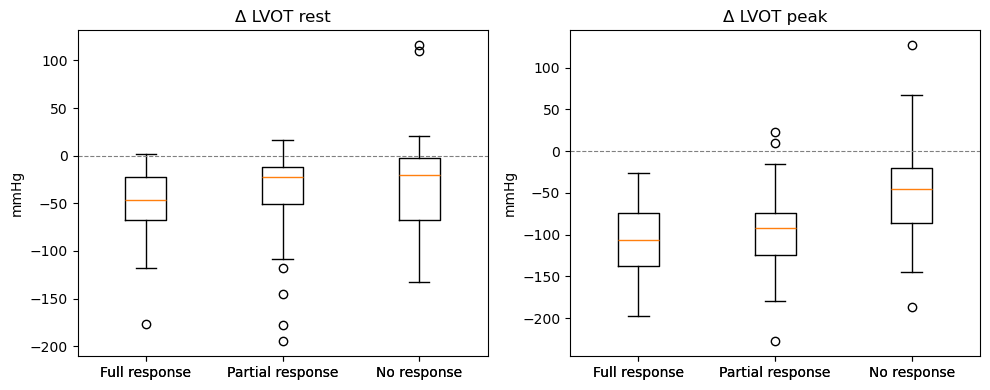

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

delta_vars = [
    "LVOTrest_DELTA_rest_LVOT",
    "LVOTpeak_DELTA_peak_LVOT"
]
titles = ["Δ LVOT rest", "Δ LVOT peak"]

for ax, var, title in zip(axes, delta_vars, titles):
    data_to_plot = [
        df.loc[df["response_group"] == g, var].dropna()
        for g in groups
    ]
    ax.boxplot(data_to_plot, labels=[groups[g] for g in groups])
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("mmHg")

plt.tight_layout()
plt.show()

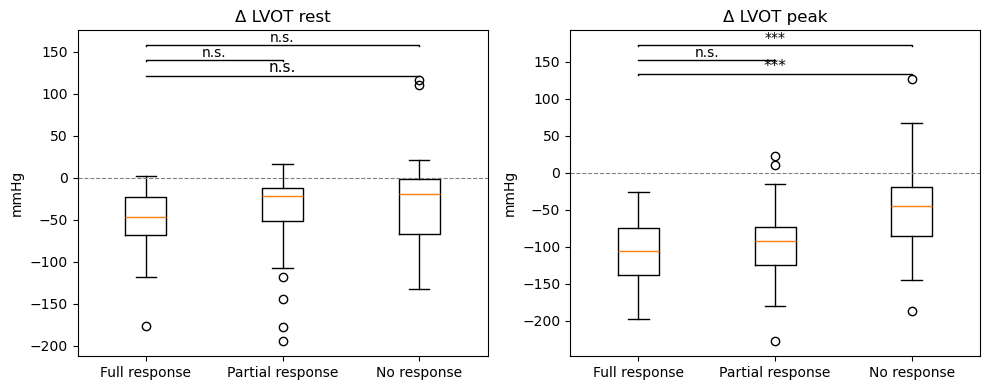

In [40]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False)

delta_vars = [
    "LVOTrest_DELTA_rest_LVOT",
    "LVOTpeak_DELTA_peak_LVOT"
]
titles = ["Δ LVOT rest", "Δ LVOT peak"]

# Mapping: response_group -> Position im Plot
group_ids   = [1, 2, 3]
group_labels = [groups[g] for g in group_ids]

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

for ax, var, title in zip(axes, delta_vars, titles):
    # Daten pro Gruppe
    data_to_plot = [
        df.loc[df["response_group"] == g, var].dropna()
        for g in group_ids
    ]

    # Boxplot
    bp = ax.boxplot(data_to_plot, labels=group_labels)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("mmHg")

    # Maximalwert für Platzierung der Balken
    y_max = max([np.max(s) for s in data_to_plot if len(s) > 0])
    step = (abs(y_max) + 5) * 0.15  # vertikaler Abstand zwischen Balken
    base = y_max + 5

    # 1) Globaler Kruskal–Wallis
    if all(len(s) > 0 for s in data_to_plot):
        stat, p_kw = stats.kruskal(*data_to_plot)
        stars_kw = p_to_stars(p_kw)
        y_bar = base
        x1, x2 = 1, 3
        ax.plot([x1, x1, x2, x2], [y_bar, y_bar + 0.5, y_bar + 0.5, y_bar],
                color="black", linewidth=1)
        ax.text((x1 + x2) / 2, y_bar + 0.7, stars_kw,
                ha="center", va="bottom", fontsize=11)

    # 2) Paarweise Vergleiche
    # Full (1) vs Partial (2)
    s_full    = data_to_plot[0]
    s_partial = data_to_plot[1]
    if len(s_full) > 0 and len(s_partial) > 0:
        stat, p_fp = stats.mannwhitneyu(s_full, s_partial, alternative="two-sided")
        stars_fp = p_to_stars(p_fp)
        y_bar = base + step
        x1, x2 = 1, 2
        ax.plot([x1, x1, x2, x2], [y_bar, y_bar + 0.5, y_bar + 0.5, y_bar],
                color="black", linewidth=1)
        ax.text((x1 + x2) / 2, y_bar + 0.7, stars_fp,
                ha="center", va="bottom", fontsize=10)

    # Full (1) vs No (3)
    s_no = data_to_plot[2]
    if len(s_full) > 0 and len(s_no) > 0:
        stat, p_fn = stats.mannwhitneyu(s_full, s_no, alternative="two-sided")
        stars_fn = p_to_stars(p_fn)
        y_bar = base + 2 * step
        x1, x2 = 1, 3
        ax.plot([x1, x1, x2, x2], [y_bar, y_bar + 0.5, y_bar + 0.5, y_bar],
                color="black", linewidth=1)
        ax.text((x1 + x2) / 2, y_bar + 0.7, stars_fn,
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Verlauf von NYHA according to groups 

In [41]:
df["NYHA_vor_TASH"] = pd.to_numeric(df["NYHA_vor_TASH"], errors="coerce").astype("Int64")
df["NYHA_last_FU"]  = pd.to_numeric(df["NYHA_last_FU"],  errors="coerce").astype("Int64")

df["NYHA_DELTA"] = df["NYHA_vor_TASH"] - df["NYHA_last_FU"]  # positive Werte = Verbesserung

In [42]:
import numpy as np
import pandas as pd
from scipy import stats

nyha_vars = [
    "NYHA_vor_TASH",
    "NYHA_last_FU",
    "NYHA_DELTA"
]

rows = []
for var in nyha_vars:
    row = {"Variable": var, "Type": "ordinal/continuous"}
    for g, g_name in groups.items():  # {1:"Full",2:"Partial",3:"No"}
        s = df.loc[df["response_group"] == g, var].dropna()
        if s.size > 0:
            median = np.median(s)
            q1 = np.percentile(s, 25)
            q3 = np.percentile(s, 75)
            row[g_name] = f"{median:.1f} [{q1:.1f}; {q3:.1f}]"
        else:
            row[g_name] = ""
    samples = [df.loc[df["response_group"] == g, var].dropna() for g in groups]
    if all(len(s) > 0 for s in samples):
        stat, p = stats.kruskal(*samples)
        row["p_value"] = f"{p:.3f}"
    else:
        row["p_value"] = ""
    rows.append(row)

nyha_table = pd.DataFrame(rows)
nyha_table

,Variable,Type,Full response,Partial response,No response,p_value
0,NYHA_vor_TASH,ordinal/continuous,2.0 [2.0; 3.0],3.0 [2.0; 3.0],3.0 [2.0; 3.0],0.117
1,NYHA_last_FU,ordinal/continuous,1.0 [1.0; 1.0],2.0 [2.0; 3.0],2.0 [2.0; 3.0],0.000
2,NYHA_DELTA,ordinal/continuous,1.0 [1.0; 2.0],1.0 [0.0; 1.0],0.0 [0.0; 0.0],0.000


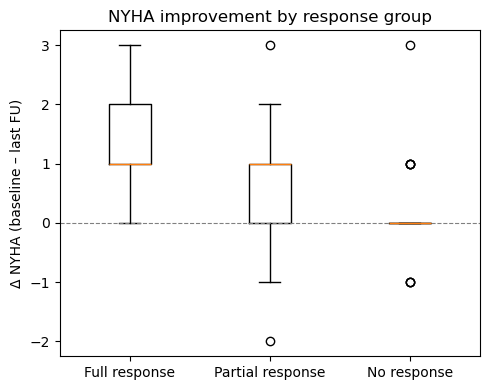

In [43]:
import matplotlib.pyplot as plt

data_to_plot = [
    df.loc[df["response_group"] == g, "NYHA_DELTA"].dropna()
    for g in groups
]

plt.figure(figsize=(5,4))
plt.boxplot(data_to_plot, labels=[groups[g] for g in groups])
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.ylabel("Δ NYHA (baseline – last FU)")
plt.title("NYHA improvement by response group")
plt.tight_layout()
plt.show()

In [44]:
import pandas as pd

df_nyha = df[["response_group", "NYHA_vor_TASH", "NYHA_last_FU"]].dropna().copy()
df_nyha["NYHA_vor_TASH"] = df_nyha["NYHA_vor_TASH"].astype(int)
df_nyha["NYHA_last_FU"]  = df_nyha["NYHA_last_FU"].astype(int)

transitions = {}
for g, g_name in groups.items():
    sub = df_nyha[df_nyha["response_group"] == g]
    if sub.empty:
        continue
    mat = pd.crosstab(sub["NYHA_vor_TASH"], sub["NYHA_last_FU"])
    transitions[g_name] = mat

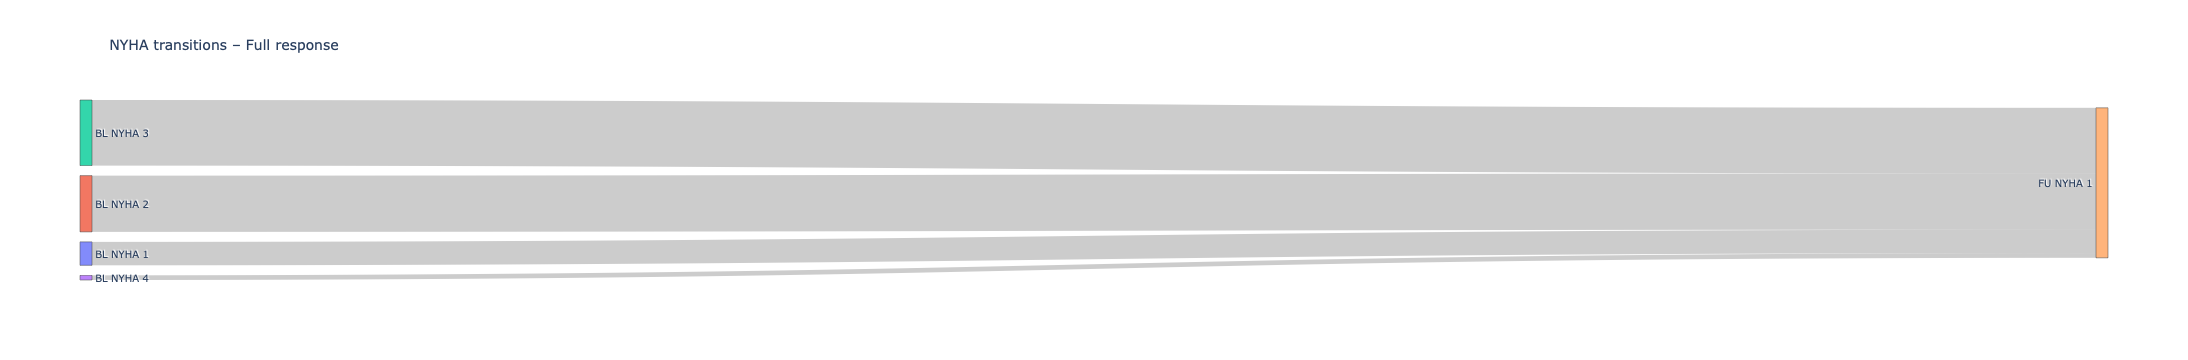

In [45]:
import plotly.graph_objects as go

g_name = "Full response"
mat = transitions[g_name]

sources = []
targets = []
values  = []

# Nodes: 0-3 = BL NYHA I–IV, 4-7 = last FU NYHA I–IV
for bl in range(1, 5):
    for fu in range(1, 5):
        if bl in mat.index and fu in mat.columns:
            v = mat.loc[bl, fu]
            if v > 0:
                sources.append(bl-1)
                targets.append(4 + fu-1)
                values.append(v)

labels = [f"BL NYHA {i}" for i in range(1,5)] + [f"FU NYHA {i}" for i in range(1,5)]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=10, thickness=12),
    link=dict(source=sources, target=targets, value=values)
)])
fig.update_layout(title_text=f"NYHA transitions – {g_name}", font_size=10)
fig.show()

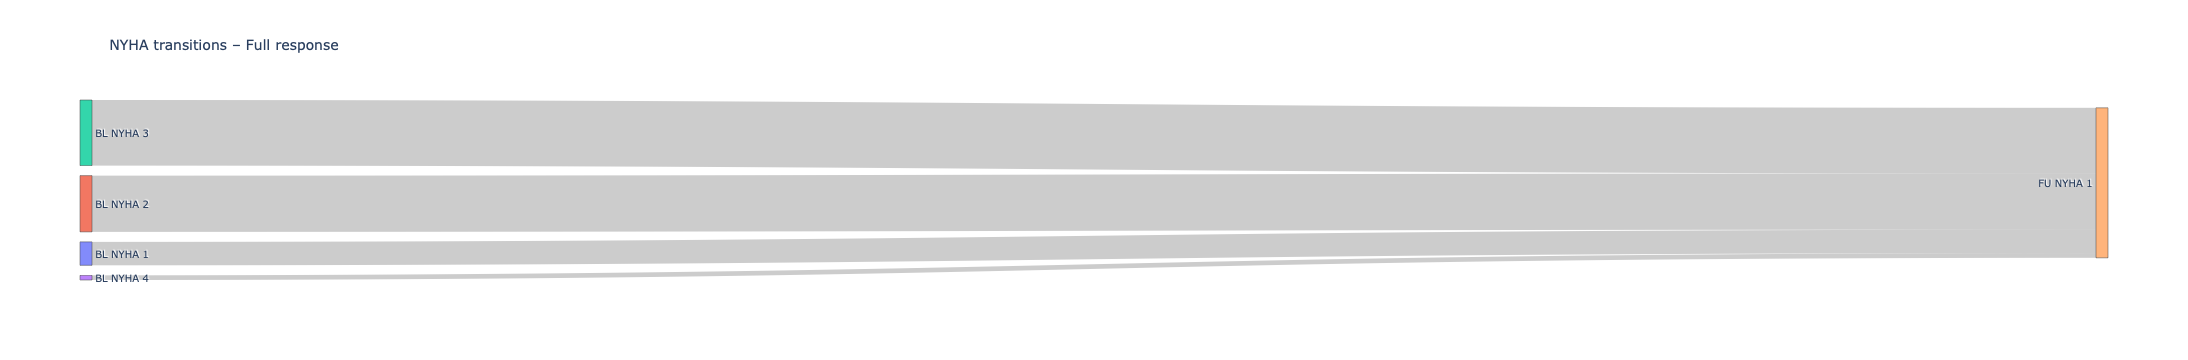

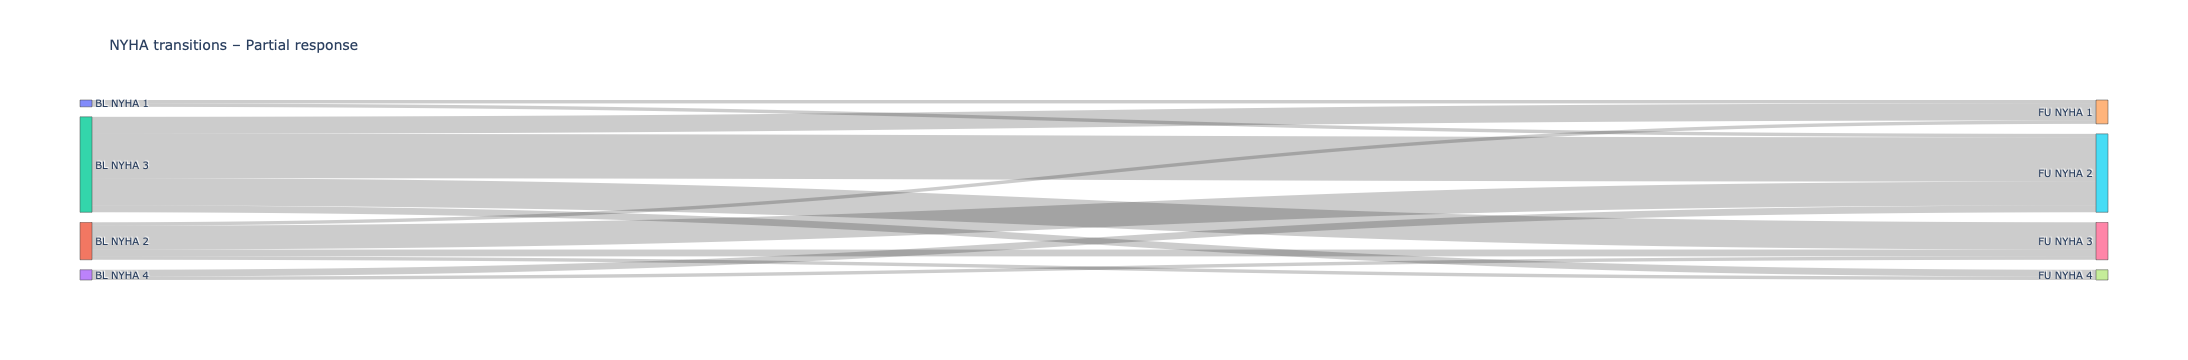

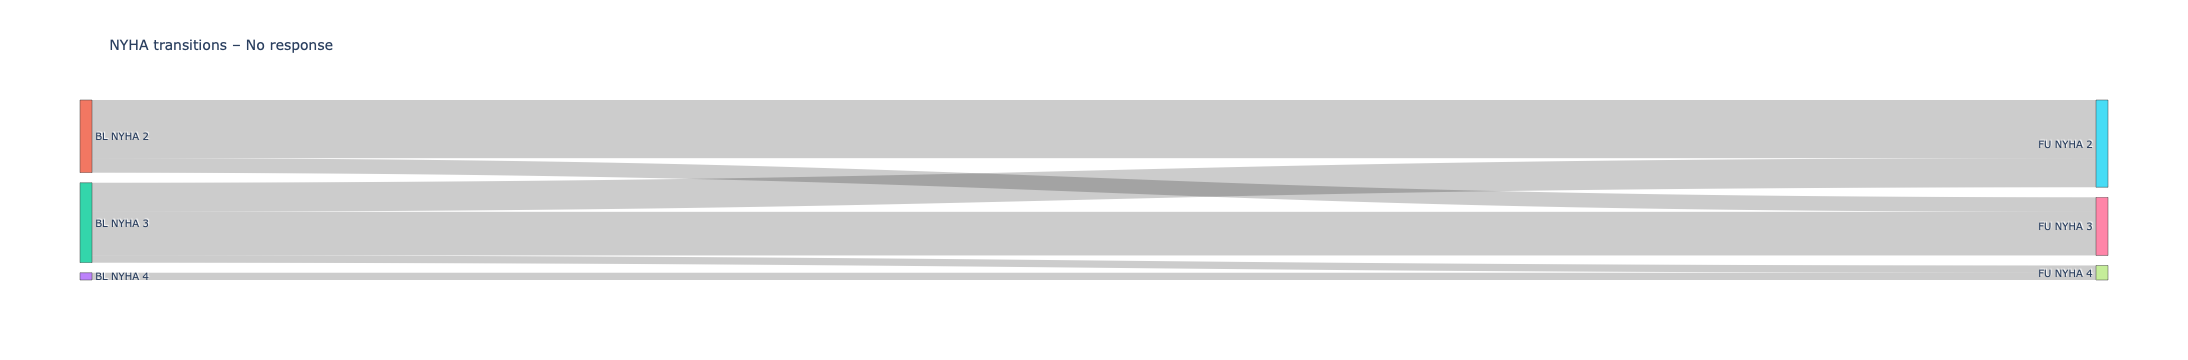

In [46]:
import plotly.graph_objects as go

for g, g_name in groups.items():  # groups = {1:"Full response", 2:"Partial response", 3:"No response"}
    if g_name not in transitions:
        continue
    mat = transitions[g_name]

    sources = []
    targets = []
    values  = []

    # Nodes: 0–3 = BL NYHA I–IV, 4–7 = FU NYHA I–IV
    for bl in range(1, 5):
        for fu in range(1, 5):
            if bl in mat.index and fu in mat.columns:
                v = mat.loc[bl, fu]
                if v > 0:
                    sources.append(bl - 1)
                    targets.append(4 + fu - 1)
                    values.append(v)

    if not values:
        continue  # falls eine Gruppe keine Daten hat

    labels = [f"BL NYHA {i}" for i in range(1,5)] + [f"FU NYHA {i}" for i in range(1,5)]

    fig = go.Figure(data=[go.Sankey(
        node=dict(label=labels, pad=10, thickness=12),
        link=dict(source=sources, target=targets, value=values)
    )])
    fig.update_layout(title_text=f"NYHA transitions – {g_name}", font_size=10)
    fig.show()

### NYHA Verlauf schöner machen: 

In [47]:
# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================


In [48]:
nyha_colors = {
    1: "#4CAF50",  # grün
    2: "#FFC107",  # gelb
    3: "#FF9800",  # orange
    4: "#F44336"   # rot
}

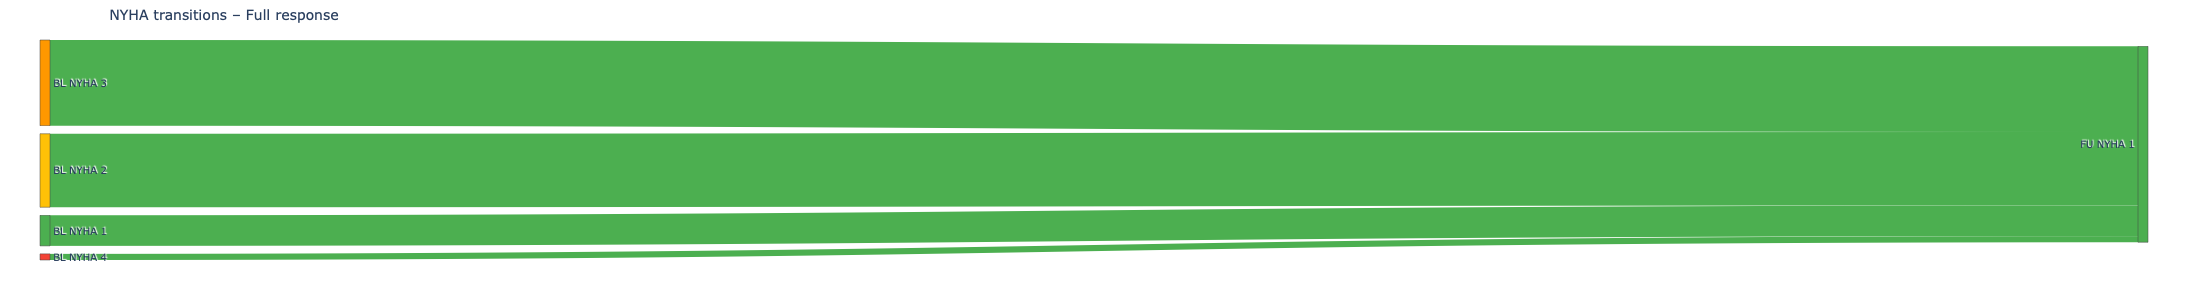

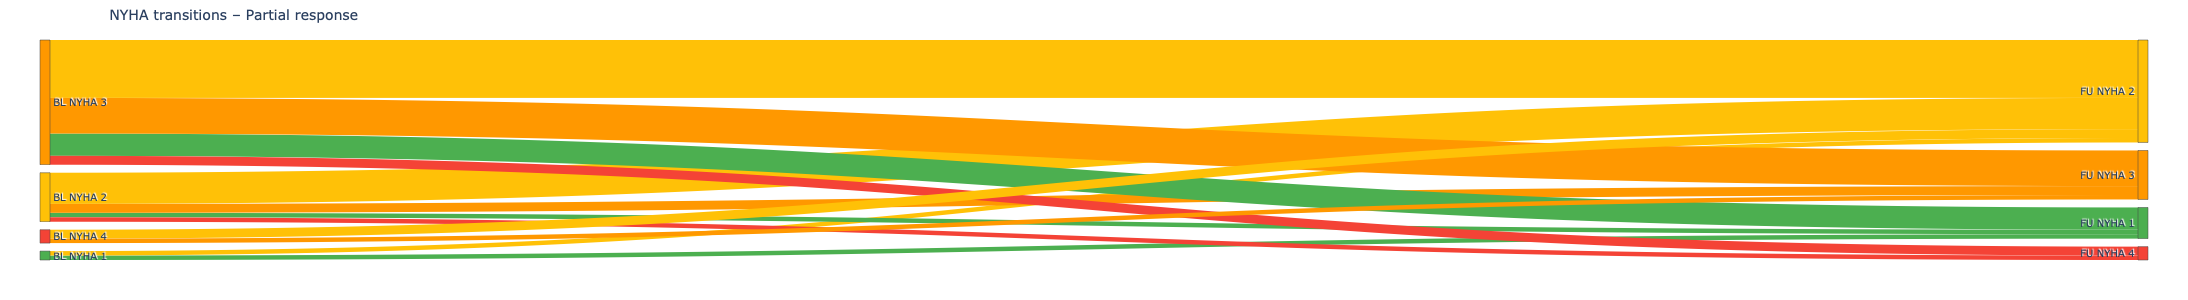

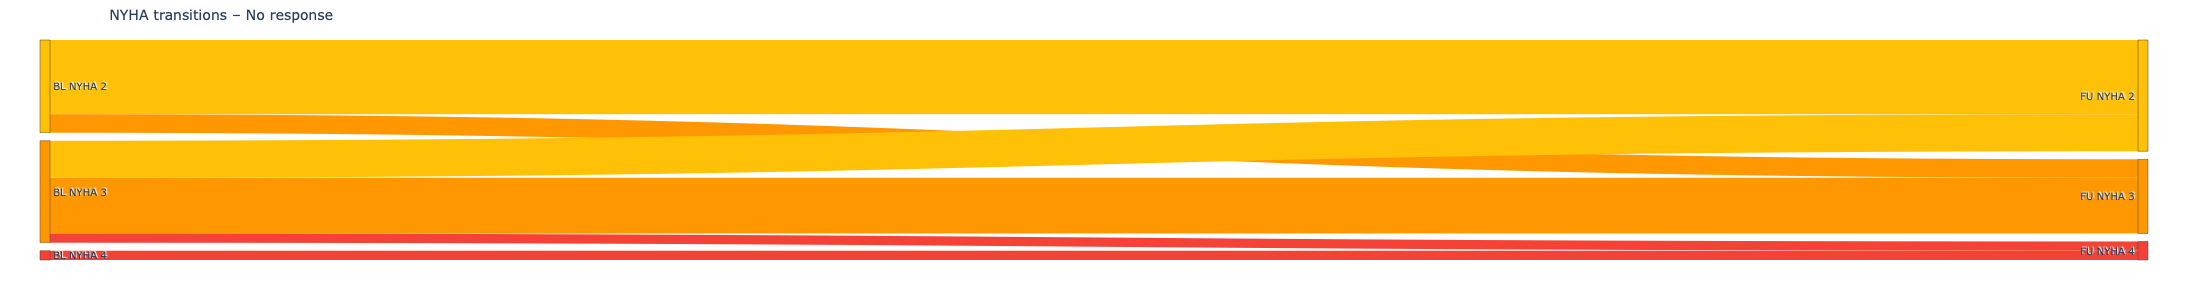

In [49]:
import plotly.graph_objects as go

for g, g_name in groups.items():
    if g_name not in transitions:
        continue
    mat = transitions[g_name]

    sources = []
    targets = []
    values  = []
    link_colors = []

    # Nodes: 0-3 = BL NYHA I–IV, 4-7 = FU NYHA I–IV
    for bl in range(1, 5):
        for fu in range(1, 5):
            if bl in mat.index and fu in mat.columns:
                v = mat.loc[bl, fu]
                if v > 0:
                    sources.append(bl - 1)
                    targets.append(4 + fu - 1)
                    values.append(v)
                    # Farbe der Kante nach Ziel-NYHA (oder nach BL, je nach Geschmack)
                    link_colors.append(nyha_colors[fu])

    if not values:
        continue

    labels = [f"BL NYHA {i}" for i in range(1, 5)] + [f"FU NYHA {i}" for i in range(1, 5)]

    # Node-Farben: BL 1–4, FU 1–4 mit gleicher Skala
    node_colors = (
        [nyha_colors[i] for i in range(1, 5)] +
        [nyha_colors[i] for i in range(1, 5)]
    )

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=labels,
            pad=8,
            thickness=10,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])

    fig.update_layout(
        title_text=f"NYHA transitions – {g_name}",
        font_size=10,
        width=600,   # schmaler fürs Supplement
        height=300,
        margin=dict(l=40, r=40, t=40, b=40)
    )
    fig.show()

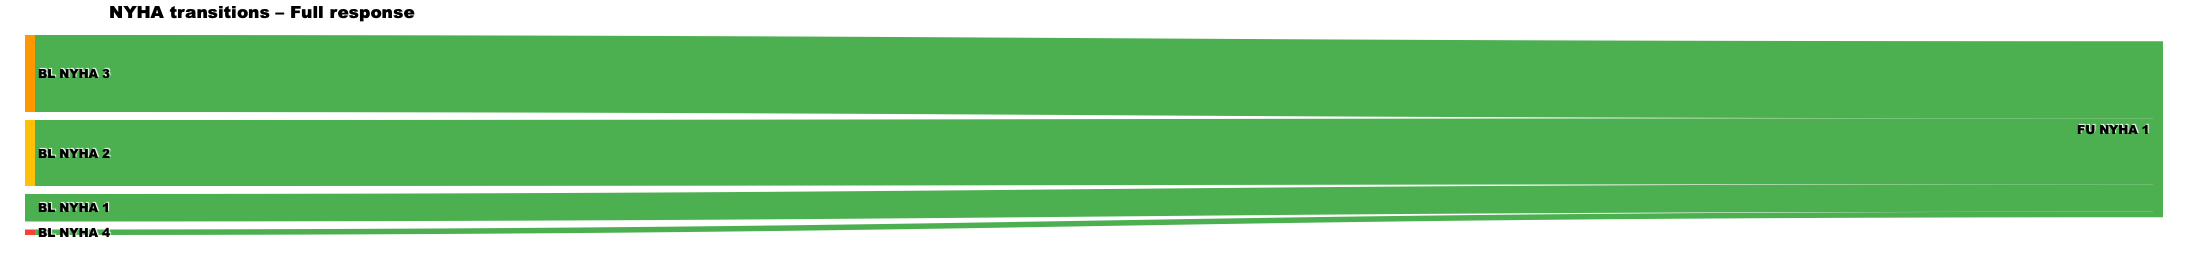

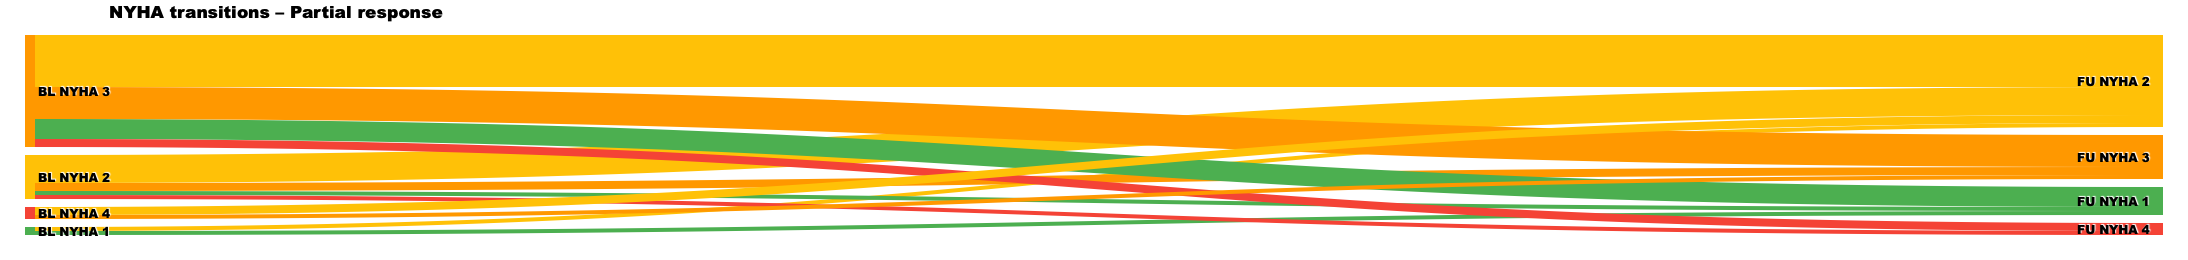

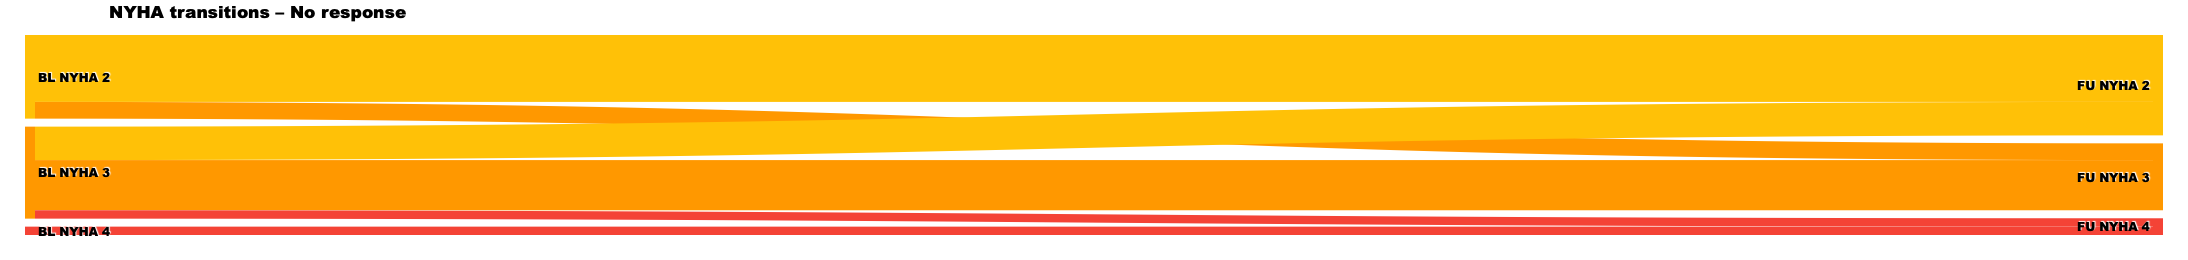

In [50]:
import plotly.graph_objects as go

for g, g_name in groups.items():
    if g_name not in transitions:
        continue
    mat = transitions[g_name]

    sources = []
    targets = []
    values  = []
    link_colors = []

    # Nodes: 0-3 = BL NYHA I–IV, 4-7 = FU NYHA I–IV
    for bl in range(1, 5):
        for fu in range(1, 5):
            if bl in mat.index and fu in mat.columns:
                v = mat.loc[bl, fu]
                if v > 0:
                    sources.append(bl - 1)
                    targets.append(4 + fu - 1)
                    values.append(v)
                    link_colors.append(nyha_colors[fu])

    if not values:
        continue

    labels = [f"BL NYHA {i}" for i in range(1, 5)] + [f"FU NYHA {i}" for i in range(1, 5)]

    node_colors = (
        [nyha_colors[i] for i in range(1, 5)] +
        [nyha_colors[i] for i in range(1, 5)]
    )

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=labels,
            pad=8,
            thickness=10,
            color=node_colors,
            line=dict(color="rgba(0,0,0,0)", width=0)   # keine Umrandung
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])

    fig.update_layout(
        title_text=f"NYHA transitions – {g_name}",
        font=dict(
            size=12,              # etwas größer
            color="black",        # kräftiger
            family="Arial Black, Arial, sans-serif"   # pseudo-fett
        ),
        width=400,               # schmaler
        height=260,              # etwas kompakter
        margin=dict(l=25, r=25, t=35, b=25),
        paper_bgcolor="white",
        plot_bgcolor="white"
    )

    fig.show()

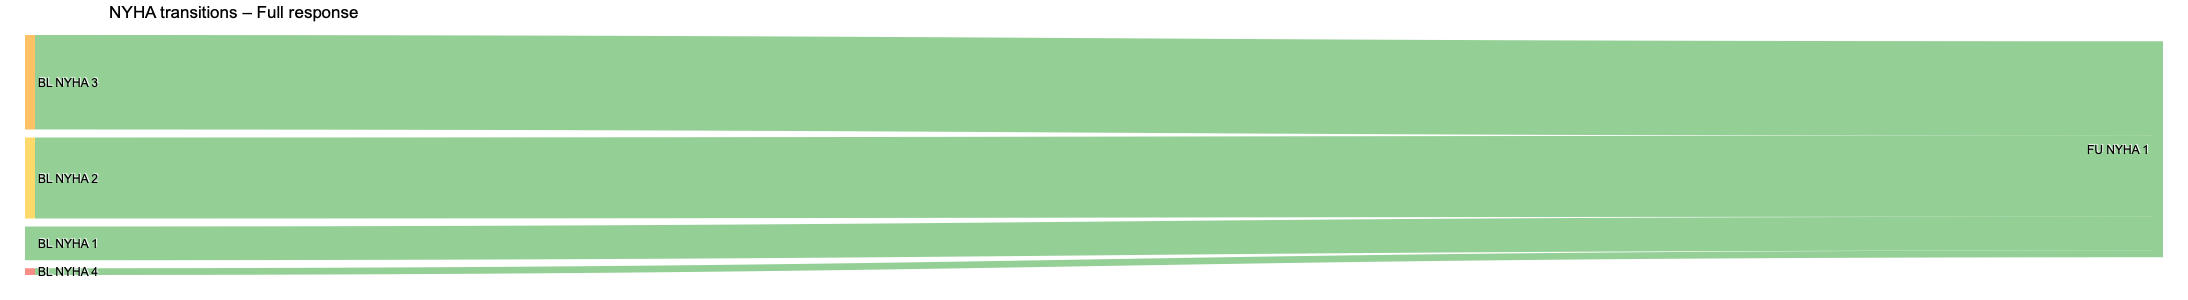

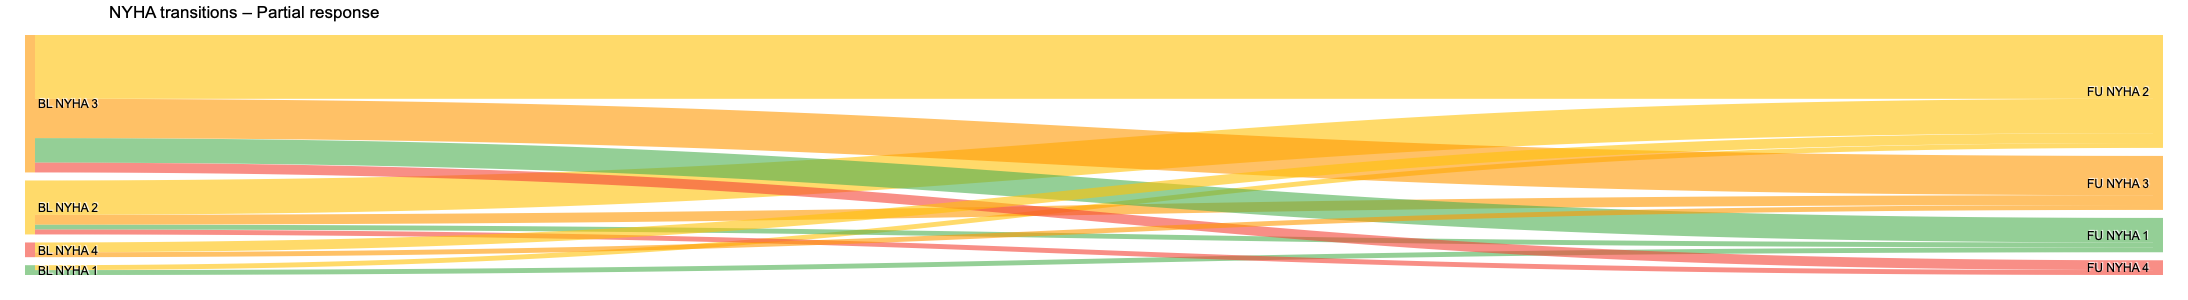

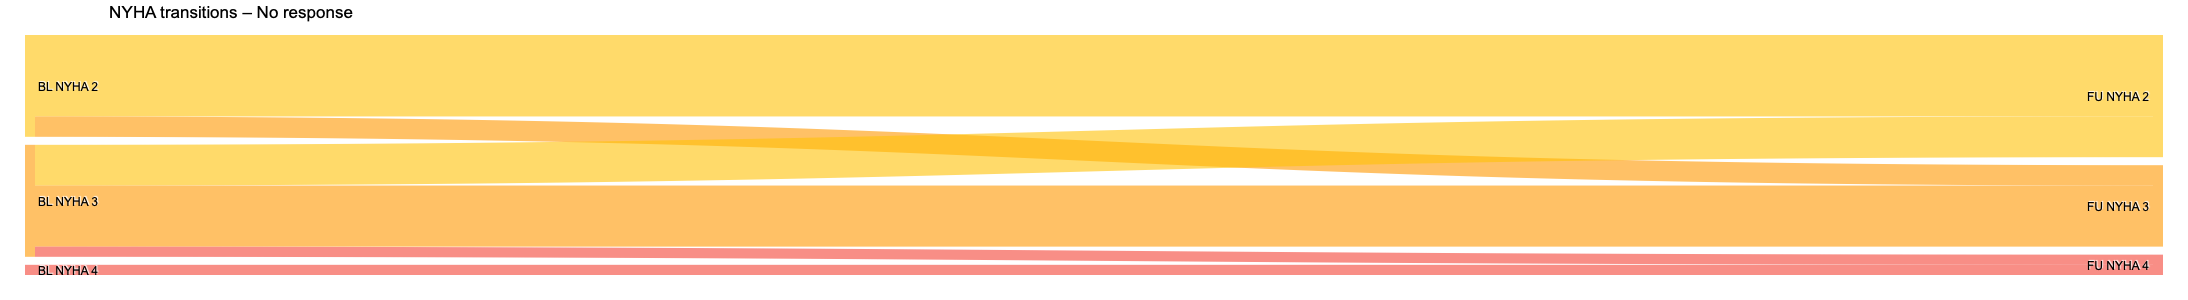

In [54]:
import plotly.graph_objects as go

# ursprüngliche NYHA-Farben (Hex)
nyha_colors_hex = {
    1: "#4CAF50",  # grün
    2: "#FFC107",  # gelb
    3: "#FF9800",  # orange
    4: "#F44336"   # rot
}

def fade_hex(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# "ausgebleichte" Farben als RGBA
nyha_colors = {k: fade_hex(v, alpha=0.6) for k, v in nyha_colors_hex.items()}

for g, g_name in groups.items():
    if g_name not in transitions:
        continue
    mat = transitions[g_name]

    sources = []
    targets = []
    values  = []
    link_colors = []

    # Nodes: 0-3 = BL NYHA I–IV, 4-7 = FU NYHA I–IV
    for bl in range(1, 5):
        for fu in range(1, 5):
            if bl in mat.index and fu in mat.columns:
                v = mat.loc[bl, fu]
                if v > 0:
                    sources.append(bl - 1)
                    targets.append(4 + fu - 1)
                    values.append(v)
                    # etwas hellere Farbe nach Ziel-NYHA
                    link_colors.append(nyha_colors[fu])

    if not values:
        continue

    labels = [f"BL NYHA {i}" for i in range(1, 5)] + [f"FU NYHA {i}" for i in range(1, 5)]

    node_colors = (
        [nyha_colors[i] for i in range(1, 5)] +
        [nyha_colors[i] for i in range(1, 5)]
    )

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=labels,
            pad=8,
            thickness=10,
            color=node_colors,
            line=dict(color="rgba(0,0,0,0)", width=0)
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])

    fig.update_layout(
        title_text=f"NYHA transitions – {g_name}",
        font=dict(
            size=12,
            color="black",
            family="Arial, sans-serif"
        ),
        width=350,
        height=300,
        margin=dict(l=25, r=25, t=35, b=25),
        paper_bgcolor="white",
        plot_bgcolor="white"
    )

    fig.show()

In [55]:
import os
import kaleido

out_dir = "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results"
os.makedirs(out_dir, exist_ok=True)

pdf_path = os.path.join(out_dir, "NYHA_transitions_response_groups.pdf")
png_path = os.path.join(out_dir, "NYHA_transitions_response_groups.png")

# PDF mit >300-dpi-Äquivalent
fig.write_image(pdf_path, format="pdf", scale=3)

# optional: sehr hoch aufgelöstes PNG (~600-dpi-Äquivalent)
fig.write_image(png_path, format="png", scale=6)

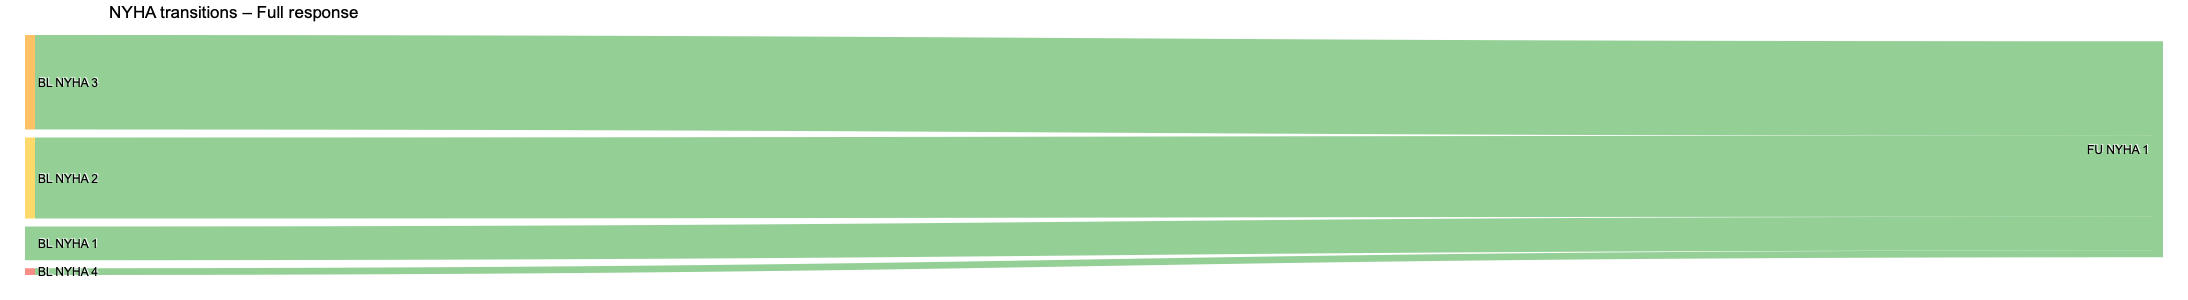

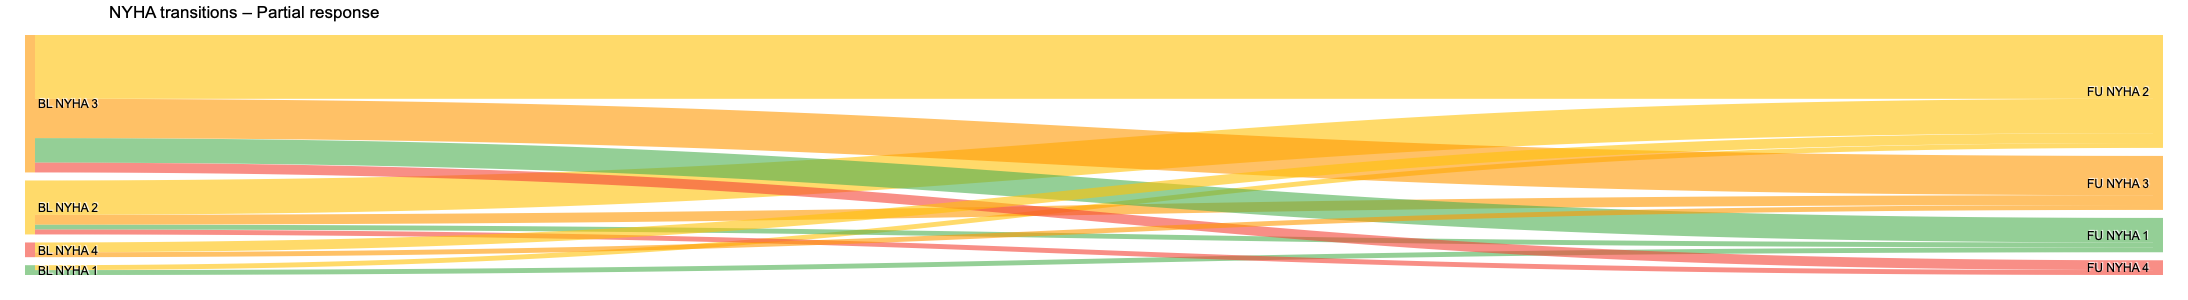

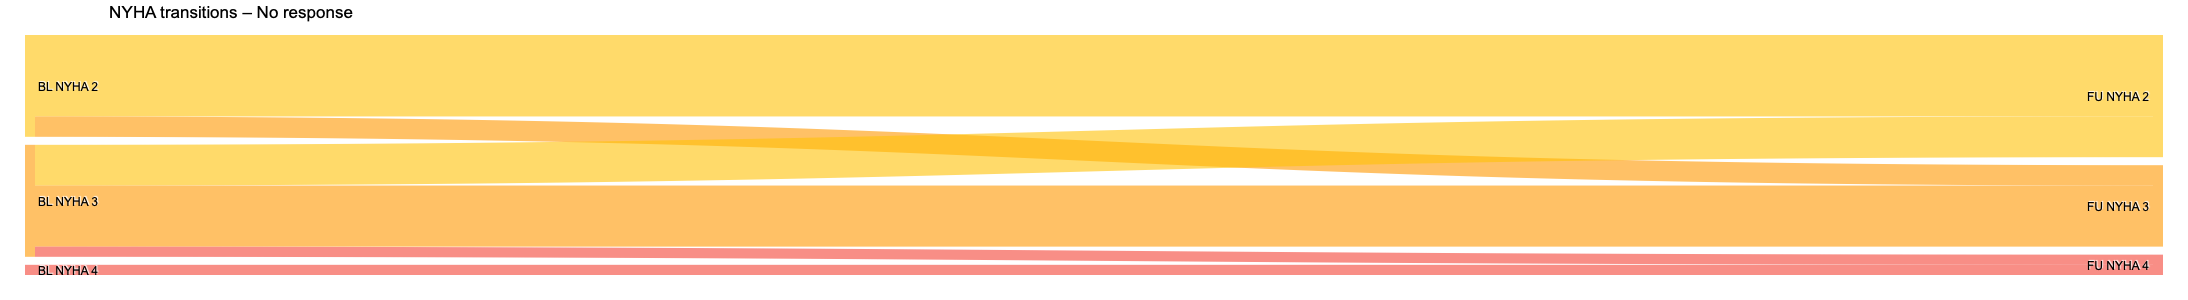

In [56]:
import plotly.graph_objects as go
import os
import kaleido  # nur damit die Engine geladen ist

out_dir = "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results"
os.makedirs(out_dir, exist_ok=True)

# ursprüngliche NYHA-Farben (Hex)
nyha_colors_hex = {
    1: "#4CAF50",  # grün
    2: "#FFC107",  # gelb
    3: "#FF9800",  # orange
    4: "#F44336"   # rot
}

def fade_hex(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# "ausgebleichte" Farben als RGBA
nyha_colors = {k: fade_hex(v, alpha=0.6) for k, v in nyha_colors_hex.items()}

for g, g_name in groups.items():
    if g_name not in transitions:
        continue
    mat = transitions[g_name]

    sources = []
    targets = []
    values  = []
    link_colors = []

    # Nodes: 0-3 = BL NYHA I–IV, 4-7 = FU NYHA I–IV
    for bl in range(1, 5):
        for fu in range(1, 5):
            if bl in mat.index and fu in mat.columns:
                v = mat.loc[bl, fu]
                if v > 0:
                    sources.append(bl - 1)
                    targets.append(4 + fu - 1)
                    values.append(v)
                    link_colors.append(nyha_colors[fu])

    if not values:
        continue

    labels = [f"BL NYHA {i}" for i in range(1, 5)] + [f"FU NYHA {i}" for i in range(1, 5)]

    node_colors = (
        [nyha_colors[i] for i in range(1, 5)] +
        [nyha_colors[i] for i in range(1, 5)]
    )

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=labels,
            pad=8,
            thickness=10,
            color=node_colors,
            line=dict(color="rgba(0,0,0,0)", width=0)
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])

    fig.update_layout(
        title_text=f"NYHA transitions – {g_name}",
        font=dict(
            size=12,
            color="black",
            family="Arial, sans-serif"
        ),
        width=350,
        height=300,
        margin=dict(l=25, r=25, t=35, b=25),
        paper_bgcolor="white",
        plot_bgcolor="white"
    )

    fig.show()

    # sauberen Dateinamen bauen
    safe_name = g_name.replace(" ", "_").replace("/", "-")

    pdf_path = os.path.join(out_dir, f"NYHA_transitions_{safe_name}.pdf")
    png_path = os.path.join(out_dir, f"NYHA_transitions_{safe_name}.png")

    # PDF mit >300-dpi-Äquivalent
    fig.write_image(pdf_path, format="pdf", scale=3)

    # optional: hochauflösendes PNG
    fig.write_image(png_path, format="png", scale=6)

### NYHA Sankey over all 

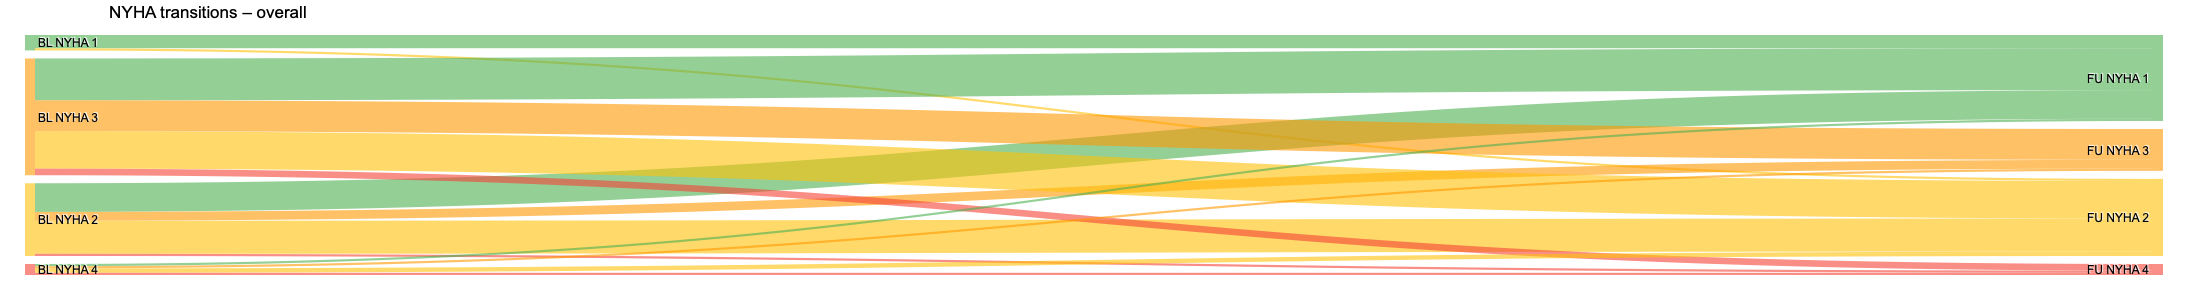

In [52]:
#NYHA_vor_TASH", "NYHA_last_FU

import plotly.graph_objects as go

# ursprüngliche NYHA-Farben (Hex)
nyha_colors_hex = {
    1: "#4CAF50",  # grün
    2: "#FFC107",  # gelb
    3: "#FF9800",  # orange
    4: "#F44336"   # rot
}

def fade_hex(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# "ausgebleichte" Farben als RGBA
nyha_colors = {k: fade_hex(v, alpha=0.6) for k, v in nyha_colors_hex.items()}

# nur gültige NYHA-Werte 1-4 verwenden
tmp = df.loc[
    df["NYHA_vor_TASH"].between(1, 4) & df["NYHA_last_FU"].between(1, 4),
    ["NYHA_vor_TASH", "NYHA_last_FU"]
].copy()

# Gesamt-Transitionsmatrix: Zeilen = BL, Spalten = FU
transitions_all = (
    tmp
    .value_counts(["NYHA_vor_TASH", "NYHA_last_FU"])
    .unstack(fill_value=0)
    .reindex(index=[1, 2, 3, 4], columns=[1, 2, 3, 4], fill_value=0)
)

mat = transitions_all

sources = []
targets = []
values  = []
link_colors = []

# Nodes: 0-3 = BL NYHA I–IV, 4-7 = FU NYHA I–IV
for bl in range(1, 5):
    for fu in range(1, 5):
        if bl in mat.index and fu in mat.columns:
            v = mat.loc[bl, fu]
            if v > 0:
                sources.append(bl - 1)
                targets.append(4 + fu - 1)
                values.append(v)
                # Farbe nach Ziel-NYHA
                link_colors.append(nyha_colors[fu])

labels = [f"BL NYHA {i}" for i in range(1, 5)] + [f"FU NYHA {i}" for i in range(1, 5)]

node_colors = (
    [nyha_colors[i] for i in range(1, 5)] +
    [nyha_colors[i] for i in range(1, 5)]
)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=8,
        thickness=10,
        color=node_colors,
        line=dict(color="rgba(0,0,0,0)", width=0)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="NYHA transitions – overall",
    font=dict(
        size=12,
        color="black",
        family="Arial, sans-serif"
    ),
    width=350,
    height=300,
    margin=dict(l=25, r=25, t=35, b=25),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()

In [53]:
import os
import kaleido

out_dir = "/data2/core-med1/fibecker/fibecker/Clinical projects/TASH/Results"
os.makedirs(out_dir, exist_ok=True)

pdf_path = os.path.join(out_dir, "NYHA_transitions_overall.pdf")
png_path = os.path.join(out_dir, "NYHA_transitions_overall.png")

# PDF mit >300-dpi-Äquivalent
fig.write_image(pdf_path, format="pdf", scale=3)

# optional: sehr hoch aufgelöstes PNG (~600-dpi-Äquivalent)
fig.write_image(png_path, format="png", scale=6)

In [67]:
! /opt/micromamba/bin/python -m pip install "kaleido==0.2.1"

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 3.7 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0
